 Anomali Tespiti: Isolation Forest (İzolasyon Ormanı)

1. Nedir?
Isolation Forest, verideki **anomalileri (aykırı değerleri)** tespit etmek için kullanılan, ağaç tabanlı (Tree-based) ve **denetimsiz (unsupervised)** bir makine öğrenmesi algoritmasıdır.

 2. Nasıl Çalışır?
- Normal verileri izole etmek (ayırmak) zorken, aykırı değerleri izole etmek çok kolaydır.
- Veri setini rastgele özellikler (features) ve rastgele bölünme noktaları (split points) seçerek dallara ayırır.
- **Aykırı Değerler:** Ağacın köküne daha yakındır (az sayıda bölünme ile izole edilir, *kısa yol uzunluğu*).
- **Normal Değerler:** Ağacın daha derinlerinde yer alır (daha fazla bölünme gerektirir, *uzun yol uzunluğu*).

 3. Önemli Hiperparametreler (scikit-learn)
- `n_estimators`: Oluşturulacak ağaç sayısı (Varsayılan: 100).
- `contamination`: Veride tahmini anomali oranı (örneğin `0.05` veya `'auto'`). Karar eşiğini belirler.
- `max_samples`: Her bir ağacı eğitirken kullanılacak örnek sayısı.

 4. Bilmen Gereken Kritik Noktalar
- **Hızlı ve Verimlidir:** Yüksek boyutlu veri setlerinde ve büyük veri hacimlerinde çok hızlı çalışır.
- **Mesafe veya Yoğunluk Hesaplamaz:** KNN veya LOF gibi algoritmaların aksine mesafe/yoğunluk matrisi hesaplamadığı için karmaşıklığı düşüktür ($O(n \log n)$).
- **Çıktı Mantığı:** `predict()` fonksiyonu anomaliler için **`-1`**, normal veriler için **`1`** döndürür. `score_samples()` ise anomali skorunu verir (skor ne kadar negatifse anomali olma ihtimali o kadar yüksektir).

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

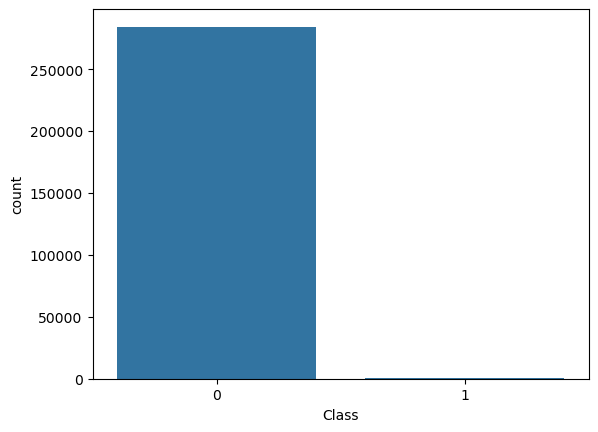

In [6]:
sns.countplot(data=df,x='Class')
plt.show()

burada cok buyuk bir dengesizlik var dengesiz verilerde dengeleme yapiyorduk ama burada asiri bir durum var denbgeleme islemni burada yapiyorum ondan dolayi isolation forest yapicaz burada

EDA

In [7]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

In [8]:
print(fraud.shape,normal.shape)

(492, 31) (284315, 31)


In [9]:
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [10]:
normal.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


bu 2 tabloda ortlaamalarina bakarak cok farkl olanlara bakicaz cunku bunlar cok etki edenler oluyor datamizda 

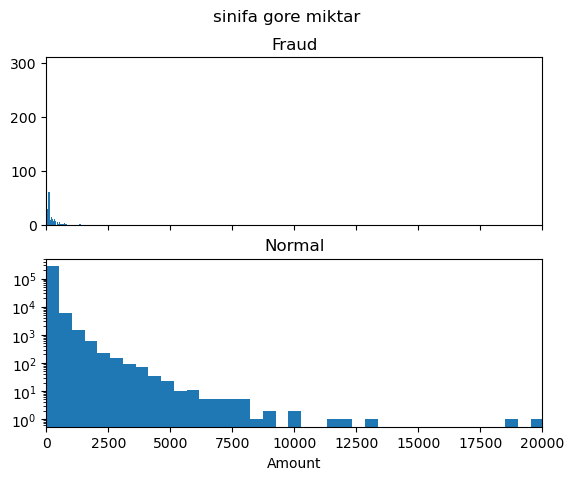

In [11]:
figure,(ax1,ax2) = plt.subplots(2,1,sharex=True)
figure.suptitle('sinifa gore miktar')
ax1.hist(fraud.Amount,bins=50)
ax1.set_title('Fraud')
ax2.hist(normal.Amount,bins=50)
ax2.set_title('Normal')
plt.xlim(0,20000)
plt.xlabel('Amount')
plt.yscale('log')
plt.show()

alt alta bu 2 tabloyu cizdiriyoruz ve normal ve dolandirma grafiklerini karsilastiriyoruz ayrica dolandircilar cok fazla dolandrimamislar 2000 dolari asan gormuyorum nerdeyse 

sharex 2 farkli tablo olmasina ragmen 2 de ayni x eksenini kullaniyor bundan dolayi isimize yariyor 

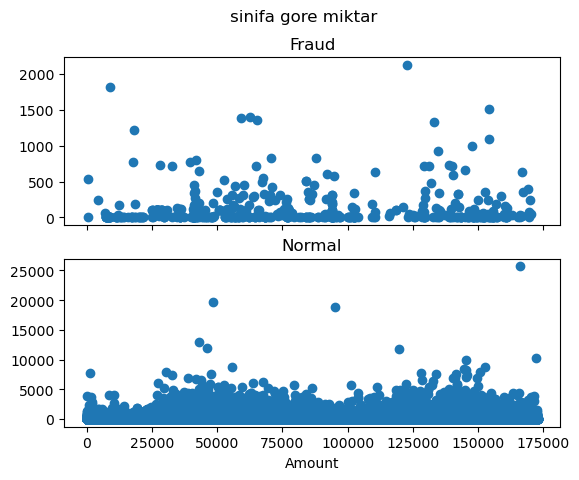

In [12]:
figure,(ax1,ax2) = plt.subplots(2,1,sharex=True)
figure.suptitle('sinifa gore miktar')
ax1.scatter(fraud.Time,fraud.Amount)
ax1.set_title('Fraud')
ax2.scatter(normal.Time,normal.Amount)
ax2.set_title('Normal')
plt.xlabel('Amount')
plt.show()

zamana gore cok buyuk bir farklilik gormuyorum cokda isimize yarami bu grafik bizim icin 

In [13]:
from sklearn.ensemble import IsolationForest

In [14]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [15]:
fraud_ratio =  0.001727

IsolationForest'ın verideki gerçek anomalileri doğru eşik değerinde yakalayabilmesi için contamination parametresine verisetindeki gerçek fraud oranını veriyoruz

In [16]:
iso  = IsolationForest(
    n_estimators=200,
    contamination=fraud_ratio,
    max_features=1.0,
    max_samples='auto',
    random_state=42,
    n_jobs = -1
)

In [17]:
X = df.drop('Class',axis=1)

In [18]:
iso.fit(X)

IsolationForest(contamination=0.001727, n_estimators=200, n_jobs=-1,
                random_state=42)

In [19]:
df['iso_row'] = iso.predict(X)

In [20]:
df['iso_row'].unique()

array([ 1, -1])

In [21]:
# 1 -> nomral
# -1 -> anomaly

bizim vermizde normaller = 0 ve anomaly = 1 di bundan dolayi bunlari cevirmem gerekiyor

In [22]:
df['iso_pred'] = df['iso_row'].map({1:0,-1:1})

In [23]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,iso_row,iso_pred
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,1,0


In [24]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,iso_row,iso_pred
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,1,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,1,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,1,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,1,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0,1,0


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X =  df.drop(['Class','iso_row','iso_pred'],axis=1)
y =  df['Class']

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [28]:
iso_test_pred = df.loc[X_test.index,'iso_pred']

In [29]:
from sklearn.metrics import classification_report

In [30]:
print(classification_report(y_test,iso_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.24      0.24      0.24       148

    accuracy                           1.00     85443
   macro avg       0.62      0.62      0.62     85443
weighted avg       1.00      1.00      1.00     85443



Recall, "Gerçekte var olan tüm fraud'ların yüzde kaçını yakalamayı başardık?" sorusunun cevabıdır.

In [31]:
df['anomaly_score'] = iso.decision_function(X)

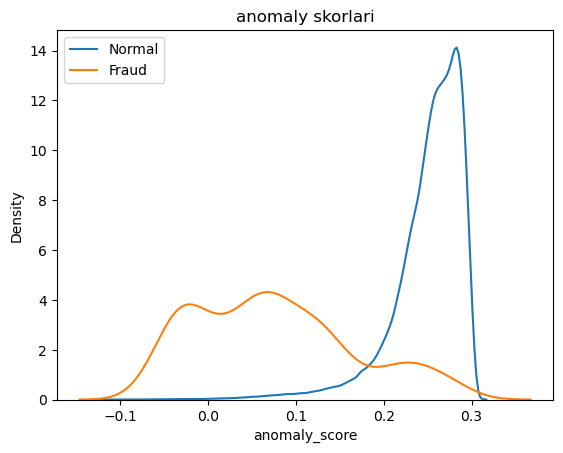

In [32]:
sns.kdeplot(df[df["Class"]==0]["anomaly_score"], label="Normal")
sns.kdeplot(df[df["Class"]==1]["anomaly_score"], label="Fraud")
plt.title('anomaly skorlari')
plt.legend()
plt.show()

Grafikte mavi ve turuncu tepe noktalarının belirgin şekilde ayrışması, IsolationForest modelinin normal işlemler ile fraud işlemleri ayırt etmede oldukça başarılı bir skor dağılımı ürettiğini gösterir

In [33]:
df['anomaly_score'].quantile(0.01)

np.float64(0.08186793737658911)

anaomaly scoru 0.08 kucuk olanalri alip bunlarr anomaly dir desem yanlis bir ifade olm,az bizim icin

In [34]:
threshold = df['anomaly_score'].quantile(0.01)

In [35]:
df['iso_custom'] = (df['anomaly_score'] < threshold).astype(int)

In [36]:
df['iso_custom'].value_counts()

iso_custom
0    281958
1      2849
Name: count, dtype: int64

In [37]:
print(classification_report(df['Class'],df['iso_custom']))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.10      0.58      0.17       492

    accuracy                           0.99    284807
   macro avg       0.55      0.79      0.58    284807
weighted avg       1.00      0.99      0.99    284807



recall degerimizi biraz daha artirmis olduk burada 

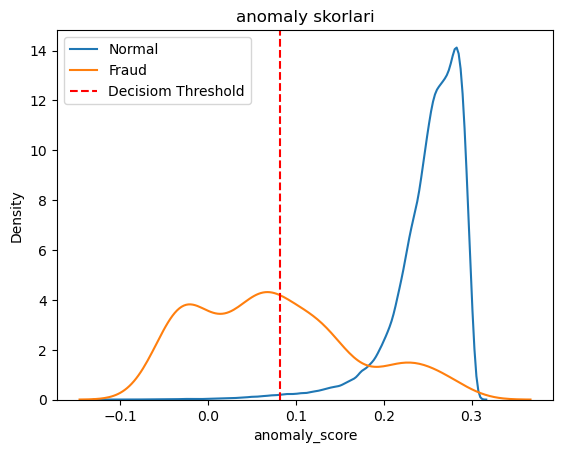

In [38]:
sns.kdeplot(df[df["Class"]==0]["anomaly_score"], label="Normal")
sns.kdeplot(df[df["Class"]==1]["anomaly_score"], label="Fraud")
plt.axvline(threshold,color='red',linestyle='--',label='Decisiom Threshold')
plt.title('anomaly skorlari')
plt.legend()
plt.show()

Bu kırmızı kesikli çizgi, modelin hangi işlemleri fraud, hangilerini normal kabul edeceğine karar veren kesin sınırdır; çizginin solunda kalan her işlem model tarafından anomali (fraud) olarak işaretlenirken, sağında kalanlar normal kabul edilir

In [40]:
df_sorted = df.sort_values('anomaly_score')

In [41]:
k = int(len(df_sorted) * 0.01 )
top_k = df_sorted.head(k)

In [42]:
top_k

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,iso_row,iso_pred,anomaly_score,iso_custom
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,...,4.554683,3.415636,31.612198,-15.430084,25691.16,0,-1,1,-0.120212,1
173353,121450.0,-28.262775,-26.551515,-15.930586,6.945207,-19.203497,13.461737,23.718783,-9.419314,5.264773,...,-3.684737,-0.106886,4.071877,-2.383081,4861.64,0,-1,1,-0.118682,1
173054,121340.0,-22.132223,-19.815536,-11.183644,4.829787,-13.128465,10.689779,18.257057,-8.685409,5.250410,...,-2.965101,0.149369,4.077221,-1.975801,4543.64,0,-1,1,-0.106926,1
176335,122723.0,-35.274010,-34.889342,-15.070015,9.211564,-6.226835,3.828063,10.778805,-6.462003,6.588395,...,-4.564506,-0.594620,1.110848,-0.714247,1676.60,0,-1,1,-0.105962,1
206255,136137.0,-40.042537,-38.430842,-21.277176,10.527243,-16.296090,8.799515,19.553200,-6.221785,6.121324,...,-4.196468,-0.851794,0.375152,-1.178134,1676.60,0,-1,1,-0.104298,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270482,164095.0,-5.156486,-4.047256,0.681539,1.835290,5.604813,-2.500778,-4.655969,-2.316873,1.409756,...,-0.765440,-1.073832,1.863624,-0.686986,21.63,0,1,0,0.081742,1
231831,146946.0,-5.944667,5.788085,-2.382159,-2.258326,-0.158975,-1.300510,1.559494,-0.762640,5.656877,...,0.587998,-0.233592,2.880563,1.176082,1.79,0,1,0,0.081772,1
199679,133081.0,-2.358533,3.313893,-3.295007,-0.346871,-0.059448,2.510808,-5.314225,-12.509177,-1.549689,...,-0.504123,-0.217408,-0.236612,0.107879,36.29,0,1,0,0.081786,1
178253,123550.0,-11.219660,1.508430,-5.736577,-2.116511,-8.195979,-0.529104,-4.133891,5.827402,-1.384015,...,0.899128,-0.086430,0.073954,-0.304958,152.65,0,1,0,0.081792,1


In [43]:
top_k['Class'].sum()

np.int64(285)

In [44]:
df['Class'].sum()

np.int64(492)

In [45]:
frauds_capture = top_k['Class'].sum()
total_frauds = df['Class'].sum()

recall_at_k = frauds_capture / total_frauds

In [46]:
recall_at_k

np.float64(0.5792682926829268)

sadece 100 de 1 ne bakarak %58 yakalamis olduk

In [48]:
percentages = np.linspace(0.001,0.05,30)
recalls = [] 

total_frauds = df['Class'].sum()

for p in percentages:
    k = int(len(df_sorted)*p)
    captured = df_sorted.head(k)['Class'].sum()
    recalls.append(captured/total_frauds)

In [49]:
recalls

[np.float64(0.17073170731707318),
 np.float64(0.3170731707317073),
 np.float64(0.38414634146341464),
 np.float64(0.4715447154471545),
 np.float64(0.5121951219512195),
 np.float64(0.5650406504065041),
 np.float64(0.6077235772357723),
 np.float64(0.6341463414634146),
 np.float64(0.6483739837398373),
 np.float64(0.6666666666666666),
 np.float64(0.6890243902439024),
 np.float64(0.7154471544715447),
 np.float64(0.7398373983739838),
 np.float64(0.758130081300813),
 np.float64(0.7703252032520326),
 np.float64(0.782520325203252),
 np.float64(0.7886178861788617),
 np.float64(0.8028455284552846),
 np.float64(0.8089430894308943),
 np.float64(0.8170731707317073),
 np.float64(0.8191056910569106),
 np.float64(0.8252032520325203),
 np.float64(0.8313008130081301),
 np.float64(0.8414634146341463),
 np.float64(0.8414634146341463),
 np.float64(0.8434959349593496),
 np.float64(0.8455284552845529),
 np.float64(0.8455284552845529),
 np.float64(0.8475609756097561),
 np.float64(0.8495934959349594)]

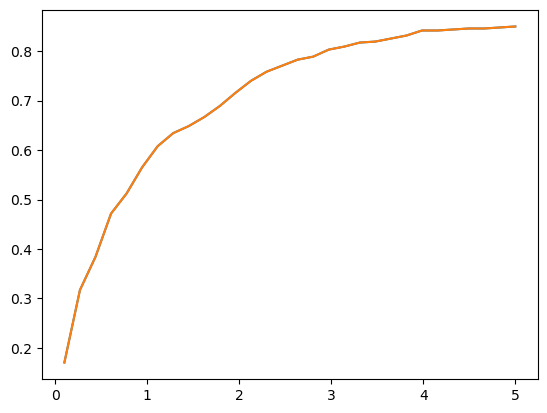

In [51]:
plt.plot(percentages * 100,recalls)
plt.show()

UNSUPERVISED LEARNING -> SUPERVISED LEARNING -> HUMAN 

Unsupervised: Bütün harcamalar içinden garip duranları bul.

Supervised: Garip duran bu harcamalara risk skoru at.

Human: Yüksek riskli veya belirsiz olanları insan kontrolünden geçir ve karara bağla.

In [54]:
from xgboost import XGBRFClassifier

In [55]:
X = df.drop(['Class','iso_row','iso_pred','iso_custom'],axis=1)
y = df['Class']

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [59]:
xgb = XGBRFClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    n_jobs = -1
)

XGBRFClassifier: Dengesiz (imbalanced) veri setleri için XGBoost tabanlı Random Forest modeli tanımlar.

 Ne İşe Yarar?
 Veride 0'lar çok, 1'ler az olduğunda; azınlık olan 1 sınıfına daha yüksek ağırlık vererek modeli dengeler.

 Neden Kullanırız?
 Modelin sadece çoğunluk olan sınıfı öğrenip azınlık sınıfı (1) gözden kaçırmasını engellemek için.

 Ne Zaman Kullanırız?
 Sınıf dağılımı dengesiz olan problemlerde (örn: Fraud/Dolandırıcılık tespiti, Churn analizi, Hasta tespiti).



In [60]:
xgb.fit(X_train,y_train)

XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=True,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=-1,
                num_parallel_tree=None, objective='binary:logistic',
                random_state=42, ...)

In [61]:
print(classification_report(y_test,xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.41      0.82      0.55       148

    accuracy                           1.00     85443
   macro avg       0.71      0.91      0.77     85443
weighted avg       1.00      1.00      1.00     85443

